# Evaluation of the Pléiades Neo → Pléiades Degradation Pipeline

**Objective.** Quantitatively assess whether simulated Pléiades images (obtained by degrading Pléiades Neo imagery) are statistically indistinguishable from real Pléiades acquisitions.

**Metrics.** Kernel Inception Distance (KID), Multi-Scale Inception Distance (MSID), Inception Score (IS), Cosine Similarity, and Euclidean Distance — all computed on SatDINO (ViT-Base/16) tile embeddings.

**Datasets.**
- `Neo_*` — Real Pléiades Neo images (baseline / high-resolution source)  
- `simulated_*` — Simulated Pléiades images produced by the degradation pipeline  
- `pl_*` — Real Pléiades images (target distribution)


## 1. Imports & Configuration

In [14]:
# --- Standard library ---
import os
import random
from glob import glob

# --- Numerical & image ---
import numpy as np
import rasterio
from PIL import Image

# --- Deep learning ---
import torch
import torchvision.transforms as T
from ultralytics import YOLO
from transformers import AutoModel
from transformers.modeling_utils import PreTrainedModel

# --- Metrics ---
from piq import KID, MSID, IS
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

# --- Dimensionality reduction & geometry ---
import umap
from scipy.spatial import ConvexHull
from shapely.geometry import Polygon

# --- Visualisation ---
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display

### 1.1 Experiment Parameters

In [15]:
# --- Data paths ---
dir_pln        = "/home/thomas/Documents/code/pleiades-boat-detection/data/scoring/diff/PLN"  # Pléiades Neo (full images)
dir_pl         = "/home/thomas/Documents/code/pleiades-boat-detection/data/scoring/diff/PL"   # Real Pléiades
dir_stochastic = "/home/thomas/Documents/code/pleiades-boat-detection/data/stochastic"         # Pre-tiled stochastic output

# --- Tiling (Neo & PL only — stochastic tiles are loaded directly from disk) ---
tile_size   = 256
nb_features = 600

# --- SatDINO backbone ---
SATDINO_MODEL = "strakajk/satdino-vit_base-16"
# Alternatives: strakajk/satdino-vit_small-16 | strakajk/satdino-vit_small-8
FMOW_MEAN = (0.3826, 0.3525, 0.3051)
FMOW_STD  = (0.1598, 0.1474, 0.1384)

# --- KID ---
KID_DEGREE      = 3
KID_GAMMA       = None
KID_COEF0       = 1
KID_VAR_AT_M    = None
KID_AVERAGE     = True
KID_N_SUBSETS   = 100
KID_SUBSET_SIZE = 300
KID_RET_VAR     = True

# --- UMAP ---
# Extremely low neighbors forces UMAP to focus strictly on micro-clusters
UMAP_N_NEIGHBORS  = 5
# 0.0 allows points that are highly similar to stack directly on top of each other
UMAP_MIN_DIST     = 0.0
# Manhattan distance evaluates grid-like absolute differences
UMAP_METRIC       = "manhattan"
# Another new random state
UMAP_RANDOM_STATE = 42

# --- Colour palette (shared across all plots) ---
COLOR_PALETTE = {
    "Real Neo (Baseline)":       "#e74c3c",
    "Real PHR (Target)":         "#3498db",
    "Simulated Physic PHR":      "#2ecc71",
    "Simulated Stochastic PHR":  "#f39c12",
}
DRAWING_ORDER = [
    "Real PHR (Target)",
    "Real Neo (Baseline)",
    "Simulated Physic PHR",
    "Simulated Stochastic PHR",
]

## 2. Utility Functions

### 2.1 Image I/O & Pre-processing

In [16]:
def read_image(path):
    with rasterio.open(path) as src:
        image = src.read()
    return image[:3].transpose(1, 2, 0)  # (H, W, 3)


def match_histogram(source, target):
    matched = np.zeros_like(source)
    for c in range(source.shape[2]):
        src_band = source[:, :, c].flatten()
        tgt_band = target[:, :, c].flatten()

        src_values, src_counts = np.unique(src_band, return_counts=True)
        tgt_values, tgt_counts = np.unique(tgt_band, return_counts=True)

        src_cdf = np.cumsum(src_counts).astype(np.float64) / src_counts.sum()
        tgt_cdf = np.cumsum(tgt_counts).astype(np.float64) / tgt_counts.sum()

        interp_tgt_values = np.interp(src_cdf, tgt_cdf, tgt_values)
        matched[:, :, c] = np.interp(src_band, src_values, interp_tgt_values).reshape(source[:, :, c].shape)

    return matched.astype(source.dtype)


def percentile_stretch(image, lower=0, upper=99.99):
    stretched = np.zeros_like(image)
    for c in range(image.shape[2]):
        non_zero_pixels = image[:, :, c][image[:, :, c] > 0]
        if len(non_zero_pixels) == 0:
            stretched[:, :, c] = image[:, :, c]
            continue
        p_low, p_high = np.percentile(non_zero_pixels, [lower, upper])
        stretched[:, :, c] = np.clip((image[:, :, c] - p_low) * 255.0 / (p_high - p_low), 0, 255)
    return stretched.astype(np.uint8)

### 2.2 Tile Extraction & Filtering

In [17]:
def delete_non_data(tile, threshold=0.01):
    """Returns True if the tile contains enough valid (non-zero) pixels."""
    no_data_pixels = np.all(tile == 0, axis=-1)
    return np.mean(no_data_pixels) < threshold


def is_single_color(tile, tolerance=2):
    """Returns True if the tile lacks texture (flat ocean, cloud, or padding)."""
    min_vals = np.min(tile, axis=(0, 1)).astype(np.int16)
    max_vals = np.max(tile, axis=(0, 1)).astype(np.int16)
    return np.all((max_vals - min_vals) < tolerance)


def cut_into_tiles(image, tile_size=64):
    tiles = []
    for i in range(0, image.shape[0], tile_size):
        for j in range(0, image.shape[1], tile_size):
            tile = image[i:i+tile_size, j:j+tile_size, :]
            if tile.shape[0] == tile_size and tile.shape[1] == tile_size:
                if delete_non_data(tile) and not is_single_color(tile):
                    tiles.append(tile)
    print(f"  {len(tiles)} valid tiles of size {tile_size}×{tile_size}")
    return np.array(tiles)

### 2.3 Visualisation Helpers

In [18]:
DOMAIN_GROUPS = {
    "Pléiades Neo":         lambda k: k.startswith("Neo") or k.startswith("IMG"),
    "Physic Simulated":     lambda k: k.startswith("Physic"),
    "Stochastic Simulated": lambda k: k.startswith("Stochastic"),
    "Real Pléiades":        lambda k: k.startswith("pl_"),
}
DOMAIN_LABELS = list(DOMAIN_GROUPS.keys())


def aggregate_to_domain_matrix(raw_matrix: np.ndarray, dataset_names: list) -> np.ndarray:
    """
    Collapse an (N, N) per-dataset matrix into a (4, 4) domain matrix.
    Each cell contains the median of all (i, j) values where dataset i belongs
    to domain-row and dataset j belongs to domain-col.
    """
    n_groups = len(DOMAIN_LABELS)
    agg = np.full((n_groups, n_groups), np.nan)
    for r, (row_label, row_fn) in enumerate(DOMAIN_GROUPS.items()):
        for c, (col_label, col_fn) in enumerate(DOMAIN_GROUPS.items()):
            vals = [
                raw_matrix[i, j]
                for i, ni in enumerate(dataset_names)
                for j, nj in enumerate(dataset_names)
                if row_fn(ni) and col_fn(nj)
            ]
            if vals:
                agg[r, c] = np.median(vals)
    return agg


def plot_aggregated_matrix(agg: np.ndarray, title: str, precision: int = 3) -> None:
    """Render the 4×4 aggregated domain matrix."""
    fig, ax = plt.subplots(figsize=(7, 6))
    valid = agg[~np.isnan(agg)]
    im = ax.imshow(agg, cmap="viridis", vmin=valid.min(), vmax=valid.max())
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xticks(range(len(DOMAIN_LABELS)))
    ax.set_yticks(range(len(DOMAIN_LABELS)))
    ax.set_xticklabels(DOMAIN_LABELS, rotation=30, ha="right", fontsize=10)
    ax.set_yticklabels(DOMAIN_LABELS, fontsize=10)

    mean_val = valid.mean()
    for r in range(len(DOMAIN_LABELS)):
        for c in range(len(DOMAIN_LABELS)):
            if not np.isnan(agg[r, c]):
                color = "white" if agg[r, c] < mean_val else "black"
                ax.text(c, r, f"{agg[r, c]:.{precision}f}",
                        ha="center", va="center", color=color, fontsize=11, fontweight="bold")

    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    fig.tight_layout()
    plt.show()


# ── Legacy helpers (kept for compute_mean_scores calls below) ──────────────
def compute_mean_scores(results, dataset_names, prefix="S2"):
    return {
        name_i: np.mean([results[i, j] for j, name_j in enumerate(dataset_names)
                         if name_j.startswith(prefix) and j != i])
        for i, name_i in enumerate(dataset_names)
    }


def hex_to_rgba(hex_color, alpha):
    hex_color = hex_color.lstrip("#")
    r, g, b = (int(hex_color[i:i+2], 16) for i in (0, 2, 4))
    return f"rgba({r},{g},{b},{alpha})"

## 3. Feature Extraction — SatDINO

Tile embeddings are extracted using **SatDINO** (ViT-Base/16 pre-trained on fMoW satellite imagery).  
Each tile is normalised with fMoW statistics before being passed through the transformer.  
The CLS token output (768-d) is used as the tile representation.

In [19]:
# Monkey-patch for older transformers compatibility
def _get_all_tied_weights_keys(self):
    val = getattr(self, "_tied_weights_keys", None)
    return val if val is not None else {}
PreTrainedModel.all_tied_weights_keys = property(_get_all_tied_weights_keys)


def build_satdino_transform():
    return T.Compose([
        T.Resize((224, 224)),
        T.ToTensor(),
        T.Normalize(mean=FMOW_MEAN, std=FMOW_STD),
    ])


def tile_to_rgb_uint8(tile):
    """(H, W, C) multi-band tile → (H, W, 3) uint8 RGB with percentile stretch."""
    
    # FIXED: Extract the first 3 channels assuming (H, W, C) shape
    if tile.shape[2] >= 3:
        rgb = tile[:, :, :3].astype(np.float32)
    else:
        # If single channel, duplicate it across 3 bands
        rgb = np.dstack([tile[:, :, 0].astype(np.float32)] * 3)

    stretched = np.zeros_like(rgb, dtype=np.uint8)
    
    for c in range(3):
        band = rgb[:, :, c]
        
        # FIXED: Use actual 2nd and 98th percentiles to avoid extreme noise outliers
        p1, p99 = np.percentile(band, 1), np.percentile(band, 99)
        
        if p99 > p1:
            band = (band - p1) / (p99 - p1)
        else:
            band = band - band.min()
            if band.max() > 0:
                band = band / band.max()
                
        stretched[:, :, c] = np.clip(band * 255, 0, 255).astype(np.uint8)
        
    # No transpose needed at the end since we stayed in (H, W, C) the whole time
    return stretched


def extract_satdino_features(tiles, batch_size=32):
    """
    Extract CLS token embeddings from SatDINO.

    Parameters
    ----------
    tiles      : (N, C, H, W) numpy array of multi-band raw tiles
    batch_size : tiles per forward pass

    Returns
    -------
    features   : (N, embed_dim) numpy array — 768-d for ViT-Base
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = AutoModel.from_pretrained(SATDINO_MODEL, trust_remote_code=True).to(device).eval()
    transform = build_satdino_transform()
    all_features = []

    for start in range(0, len(tiles), batch_size):
        batch_tiles = tiles[start:start + batch_size]
        tensors = [transform(Image.fromarray(tile_to_rgb_uint8(t), "RGB")) for t in batch_tiles]
        batch_tensor = torch.stack(tensors).to(device)

        with torch.inference_mode():
            features = model(batch_tensor)

        all_features.append(features.float().cpu().numpy())

    return np.concatenate(all_features, axis=0)


def extract_yolo_features(tiles, model):
    embeddings = []
    for tile in tiles:
        results = model.embed(tile, imgsz=640)
        embeddings.append(results[0].cpu().numpy())
        print(f"  Extracted {len(embeddings)}/{len(tiles)}")
    return embeddings

## 4. Data Loading & Feature Extraction

- **Neo / PL** full images are tiled on-the-fly with `cut_into_tiles`.
- **Stochastic** tiles are loaded directly from `dir_stochastic/<image_stem>/` — no re-tiling.
  Each sub-folder corresponds to one source image; all `.tif` files in it are individual
  pre-degraded tiles produced by `generate_stochastic.py`.

In [ ]:
from pathlib import Path

list_pln = sorted(glob(os.path.join(dir_pln, "**/*.tif"), recursive=True))
list_pl  = sorted(glob(os.path.join(dir_pl,  "**/*.tif"), recursive=True))

print(f"Found {len(list_pln)} Pléiades Neo (PLN) images and {len(list_pl)} Pléiades (PL) images.")

# ── Neo & PL: tile full images on-the-fly ───────────────────────────────
print("\n— Tiling PLN images —")
pln_tiles = [cut_into_tiles(read_image(path), tile_size) for path in list_pln]

print("\n— Tiling PL images —")
pl_tiles  = [cut_into_tiles(read_image(path), tile_size) for path in list_pl]

# ── Stochastic: read pre-tiled GeoTIFFs directly ────────────────────────
# One sub-folder per source image; each .tif is an already-degraded tile.
stochastic_dir = Path(dir_stochastic)
stochastic_folders = sorted(p for p in stochastic_dir.iterdir() if p.is_dir())

print(f"\n— Loading stochastic tiles from {len(stochastic_folders)} folder(s) —")

def load_tiles_from_folder(folder: Path) -> np.ndarray:
    """Read all .tif files in `folder` as (H, W, C) arrays, apply quality filters."""
    tiles = []
    for tif in sorted(folder.glob("*.tif")):
        with rasterio.open(tif) as src:
            arr = src.read()  # Initially (C, H, W)
            
        # Transpose to (H, W, C) for the existing filter functions
        hwc = arr[:3].transpose(1, 2, 0)
        
        if delete_non_data(hwc) and not is_single_color(hwc):
            # FIXED: Append the transposed (H, W, C) array, not the raw (C, H, W) one
            tiles.append(hwc) 
            
    return tiles

stochastic_tiles = []
for folder in stochastic_folders:
    folder_tiles = load_tiles_from_folder(folder)
    stochastic_tiles.append(folder_tiles)
    print(f"  {folder.name:<60s}  {len(folder_tiles)} valid tiles")

Found 26 Pléiades Neo (PLN) images and 6 Pléiades (PL) images.

— Tiling PLN images —
  2574 valid tiles of size 256×256
  3519 valid tiles of size 256×256
  1480 valid tiles of size 256×256
  2011 valid tiles of size 256×256
  9861 valid tiles of size 256×256
  6070 valid tiles of size 256×256
  3141 valid tiles of size 256×256
  8517 valid tiles of size 256×256
  3122 valid tiles of size 256×256
  1939 valid tiles of size 256×256
  2281 valid tiles of size 256×256
  1940 valid tiles of size 256×256
  3461 valid tiles of size 256×256
  907 valid tiles of size 256×256
  1217 valid tiles of size 256×256
  496 valid tiles of size 256×256
  694 valid tiles of size 256×256
  3522 valid tiles of size 256×256
  2157 valid tiles of size 256×256
  1070 valid tiles of size 256×256


In [ ]:
# Sample random tiles and extract SatDINO embeddings
all_sampled_tiles  = []  # (H, W, 3) uint8 — for interactive UMAP inspector
pln_features       = []
pl_features        = []
stochastic_features = []

print("— Extracting PLN features —")
for tiles in pln_tiles:
    random_tiles = random.sample(list(tiles), min(nb_features, len(tiles)))
    all_sampled_tiles.extend(random_tiles)
    pln_features.append(extract_satdino_features(random_tiles, batch_size=64))

print("\n— Extracting PL features —")
for tiles in pl_tiles:
    random_tiles = random.sample(list(tiles), min(nb_features, len(tiles)))
    all_sampled_tiles.extend(random_tiles)
    pl_features.append(extract_satdino_features(random_tiles, batch_size=64))

print("\n— Extracting Stochastic features —")
for folder_tiles in stochastic_tiles:
    if not folder_tiles:
        stochastic_features.append(np.empty((0, 768), dtype=np.float32))
        continue
    sampled = random.sample(folder_tiles, min(nb_features, len(folder_tiles)))
    # Inspector needs (H, W, 3) uint8; tile_to_rgb_uint8 handles the (C,H,W) → (H,W,3) conversion
    all_sampled_tiles.extend([tile_to_rgb_uint8(t) for t in sampled])
    stochastic_features.append(extract_satdino_features(sampled, batch_size=64))

— Extracting PLN features —


Loading weights:   0%|          | 0/151 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/151 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/151 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/151 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/151 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/151 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/151 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/151 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/151 [00:00<?, ?it/s]

## 5. Dataset Inspection

Sanity-check: visualise a sample tile from each collection.

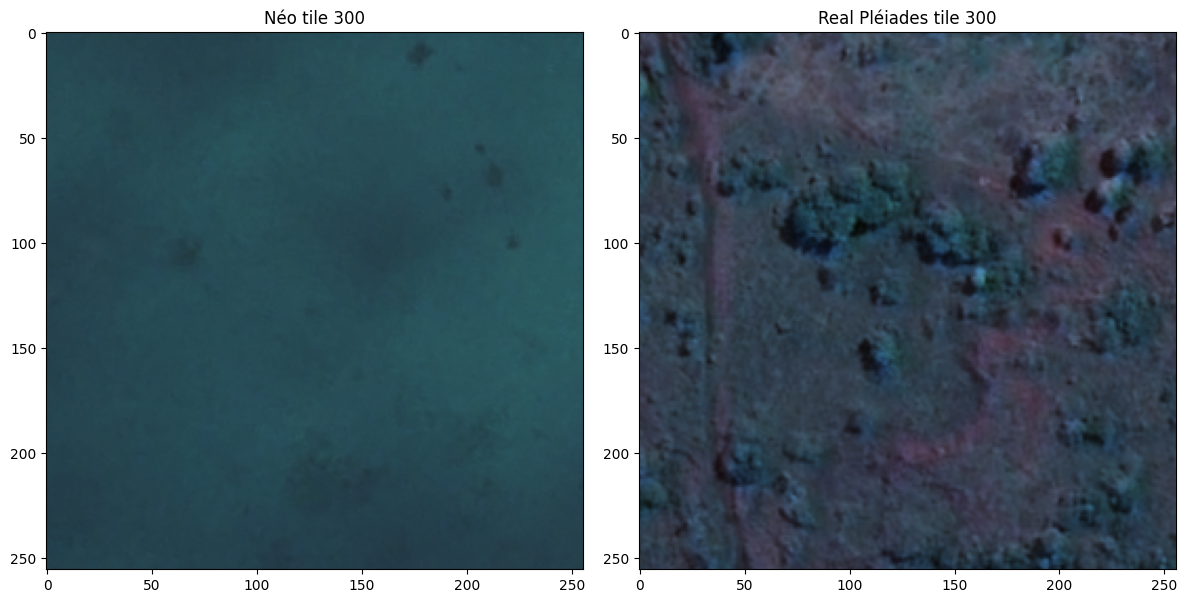

In [ ]:
tile_id = 300
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(pln_tiles[0][tile_id])
plt.title(f"Néo tile {tile_id}")
plt.subplot(1, 2, 2)
plt.imshow(pl_tiles[0][tile_id])
plt.title(f"Real Pléiades tile {tile_id}")
plt.tight_layout()
plt.show()

## 6. Dataset Assembly

In [ ]:
datasets = {}

for path, feat in zip(list_pln, pln_features):
    base_name = os.path.splitext(os.path.basename(path))[0]
    datasets[base_name] = feat

for i, path in enumerate(list_pl):
    datasets[f"pl_{i}"] = pl_features[i]

for folder, feat in zip(stochastic_folders, stochastic_features):
    if len(feat) > 0:
        datasets[f"Stochastic_{folder.name}"] = feat

dataset_names = list(datasets.keys())
nb_datasets   = len(datasets)

print("Dataset summary:")
for name, feat in datasets.items():
    print(f"  {name:<60s}  {len(feat):>4d} feature vectors")

Dataset summary:
  Neo_1                                                          600 feature vectors
  Neo_10                                                         600 feature vectors
  Neo_11                                                         600 feature vectors
  Neo_12                                                         600 feature vectors
  Neo_13                                                         600 feature vectors
  Neo_2                                                          600 feature vectors
  Neo_3                                                          600 feature vectors
  Neo_4                                                          600 feature vectors
  Neo_5                                                          600 feature vectors
  Neo_6                                                          600 feature vectors
  Neo_7                                                          600 feature vectors
  Neo_8                                         

Average pairwise L2 distance between tile embeddings across datasets. Lower means more similar.

## 12. UMAP Projection of SatDINO Embeddings

UMAP projects the high-dimensional SatDINO embeddings (768-d) into 2D for visual inspection.  
Tight clustering of *Simulated PHR* with *Real PHR* indicates successful domain transfer.  
*Parameters:* n_neighbors=15, min_dist=0.1, metric=cosine.

In [ ]:
# Aggregate features and assign semantic labels
all_features = []
labels = []

for key, emb in datasets.items():
    if key.startswith("Neo") or key.startswith("IMG"):   # Neo images (various filename prefixes)
        plot_label = "Real Neo (Baseline)"
    elif key.startswith("Physic"):
        plot_label = "Simulated Physic PHR"
    elif key.startswith("Stochastic"):
        plot_label = "Simulated Stochastic PHR"
    elif key.startswith("pl_"):
        plot_label = "Real PHR (Target)"
    else:
        print(f"Skipping unmapped key: {key}")
        continue

    if torch.is_tensor(emb):
        emb = emb.cpu().numpy()

    all_features.append(emb)
    labels.extend([plot_label] * emb.shape[0])

all_features = np.vstack(all_features)
labels = np.array(labels)

print(f"Aggregated {all_features.shape[0]} samples across {len(set(labels))} domains.")
print("Computing UMAP projection…")
reducer    = umap.UMAP(n_neighbors=UMAP_N_NEIGHBORS, min_dist=UMAP_MIN_DIST,
                       metric=UMAP_METRIC, random_state=UMAP_RANDOM_STATE)
projection = reducer.fit_transform(all_features)

Aggregated 26896 samples across 4 domains.
Computing UMAP projection…


/home/thomas/miniconda3/envs/sam3_env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/thomas/miniconda3/envs/sam3_env/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


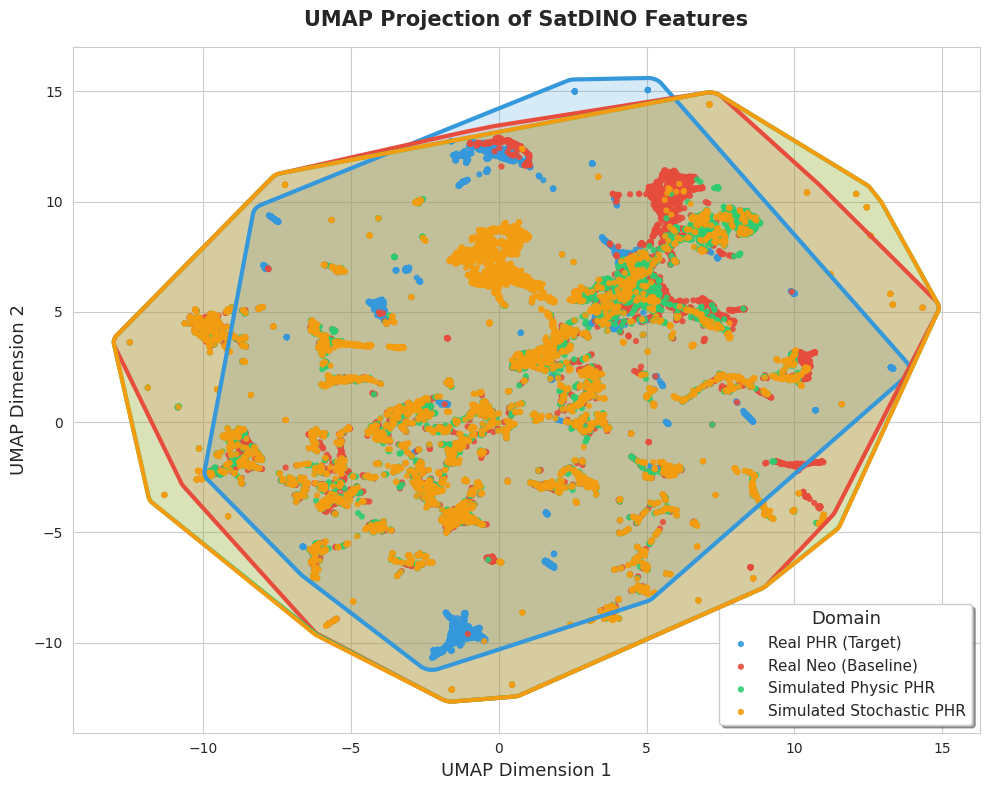

In [ ]:
sns.set_style("whitegrid")
fig_umap, ax = plt.subplots(figsize=(10, 8))

x_range = projection[:, 0].max() - projection[:, 0].min()
y_range = projection[:, 1].max() - projection[:, 1].min()
buffer_distance = max(x_range, y_range) * 0.02

# Phase 1 — filled convex hull boundaries
for i, domain in enumerate(DRAWING_ORDER):
    idx    = np.where(labels == domain)[0]
    points = projection[idx]
    if len(points) >= 4:
        hull        = ConvexHull(points)
        poly        = Polygon(points[hull.vertices])
        smooth_poly = poly.buffer(buffer_distance, join_style=1, cap_style=1)
        x_new, y_new = smooth_poly.exterior.xy
        ax.fill(x_new, y_new, color=COLOR_PALETTE[domain], alpha=0.2, zorder=1 + i)
        ax.plot(x_new, y_new, color=COLOR_PALETTE[domain], linewidth=3, zorder=20 + i)

# Phase 2 — scatter points
for i, domain in enumerate(DRAWING_ORDER):
    idx    = np.where(labels == domain)[0]
    points = projection[idx]
    ax.scatter(points[:, 0], points[:, 1], c=COLOR_PALETTE[domain],
               label=domain, alpha=0.9, s=20, edgecolors="none", zorder=10 + i)

ax.set_title("UMAP Projection of SatDINO Features", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("UMAP Dimension 1", fontsize=13)
ax.set_ylabel("UMAP Dimension 2", fontsize=13)
ax.legend(title="Domain", title_fontsize=13, fontsize=11, loc="best", frameon=True, shadow=True)

plt.tight_layout()
plt.show()

## 13. Interactive UMAP Explorer

Click any point to inspect the corresponding tile image and its RGB statistics.

In [1]:
fig_widget = go.FigureWidget()

x_range = projection[:, 0].max() - projection[:, 0].min()
y_range = projection[:, 1].max() - projection[:, 1].min()
buffer_distance = max(x_range, y_range) * 0.02

# Phase 1 — background polygons
for domain in DRAWING_ORDER:
    idx    = np.where(labels == domain)[0]
    points = projection[idx]
    if len(points) >= 4:
        hull        = ConvexHull(points)
        poly        = Polygon(points[hull.vertices])
        smooth_poly = poly.buffer(buffer_distance, join_style=1, cap_style=1)
        x_new, y_new = smooth_poly.exterior.xy
        fig_widget.add_trace(go.Scatter(
            x=list(x_new), y=list(y_new),
            mode="lines", fill="toself",
            fillcolor=hex_to_rgba(COLOR_PALETTE[domain], 0.2),
            line=dict(color=COLOR_PALETTE[domain], width=3),
            name=domain + " Boundary",
            hoverinfo="skip", showlegend=False,
        ))

# Phase 2 — scatter points
for domain in DRAWING_ORDER:
    idx = np.where(labels == domain)[0]
    fig_widget.add_trace(go.Scatter(
        x=projection[idx, 0], y=projection[idx, 1],
        mode="markers", name=domain,
        marker=dict(color=COLOR_PALETTE[domain], size=6, opacity=0.8),
        customdata=idx,
    ))

fig_widget.update_layout(
    title="Interactive UMAP: Click a dot to view the tile",
    xaxis_title="UMAP Dimension 1",
    yaxis_title="UMAP Dimension 2",
    width=800, height=650,
    template="plotly_white",
    hovermode="closest",
)

# Output panel
out = widgets.Output(layout=widgets.Layout(
    width="450px", height="580px",
    border="1px solid #ccc",
    margin="50px 0 0 20px",
))
with out:
    print("Click any point on the UMAP to load the corresponding tile here.")

# Click callback
def on_click_point(trace, points, selector):
    if not points.point_inds:
        return
    global_idx = trace.customdata[points.point_inds[0]]
    out.clear_output(wait=True)
    with out:
        try:
            tile_image = all_sampled_tiles[global_idx]

            r_min, r_max = np.min(tile_image[:, :, 0]), np.max(tile_image[:, :, 0])
            g_min, g_max = np.min(tile_image[:, :, 1]), np.max(tile_image[:, :, 1])
            b_min, b_max = np.min(tile_image[:, :, 2]), np.max(tile_image[:, :, 2])
            print(f"RGB Pixel Stats — Index: {global_idx}")
            print(f"  Red   | Min: {r_min:8.2f}, Max: {r_max:8.2f}")
            print(f"  Green | Min: {g_min:8.2f}, Max: {g_max:8.2f}")
            print(f"  Blue  | Min: {b_min:8.2f}, Max: {b_max:8.2f}")

            fig_img, ax_img = plt.subplots(figsize=(4, 4))
            ax_img.imshow(tile_image)
            ax_img.axis("off")
            ax_img.set_title(f"{labels[global_idx]}\nIndex: {global_idx}")
            plt.show()

            open_btn = widgets.Button(description="Open in PC Viewer",
                                      button_style="info", icon="external-link")
            def open_in_os(b):
                img_array = tile_image
                if img_array.dtype != np.uint8:
                    img_array = (img_array * 255).astype(np.uint8) if img_array.max() <= 1.0 else img_array.astype(np.uint8)
                Image.fromarray(img_array).show()
            open_btn.on_click(open_in_os)
            display(open_btn)

        except Exception as e:
            print(f"Error loading index {global_idx}: {e}")

for trace in fig_widget.data:
    if trace.mode == "markers":
        trace.on_click(on_click_point)

display(widgets.HBox([fig_widget, out]))

NameError: name 'go' is not defined